
# Causal Graphs (DAGs)

*A lecture note on directed acyclic graphs as the qualitative language of
causal inference — how to draw your assumptions, read them for bias, and
know exactly what to control for.*

---

## 1. Intro: draw the assumption before you run the regression

Imagine an epidemiologist tells you: "babies born to mothers who smoke
during pregnancy weigh less, on average, than babies born to non-smoking
mothers." Before you conclude smoking *causes* low birth weight, a
skeptical question: what if mothers who smoke also tend to be younger, have
less prenatal care, or less education — and *those* things affect birth
weight too? Then some (or all) of the smoking/birth-weight gap could be
these other factors riding along with smoking, not smoking itself.

The [Fundamental Problem of Causal Inference](../fundamental-problem-of-causal-inference/tutorial.ipynb)
tutorial in this domain formalizes causal effects using **potential
outcomes** — parallel worlds where a unit was, or wasn't, treated — and
shows that randomization is what lets you compare those worlds validly.
But most data isn't from an experiment. When it isn't, you need a way to
state, explicitly, *which* variables you believe affect which other
variables — your causal assumptions — before you can say what a valid
comparison even looks like. That's what a **causal directed acyclic graph
(DAG)** is: a picture of your assumptions, precise enough that it tells you
exactly what statistical move (if any) will recover a causal effect from
observational data, and exactly which "obvious" moves (like "just control
for everything") will quietly break it.

**By the end of this tutorial you'll be able to:**

- Read and draw a causal DAG: nodes as variables, arrows as direct causal
  effects.
- Recognize the three canonical 3-node building blocks — **chain**,
  **fork**, and **collider** — and state which statistical dependence
  pattern each one implies.
- Define **d-separation** and explain, with a worked argument (not just an
  assertion), why conditioning on a confounder removes bias but
  conditioning on a collider *creates* it.
- State Pearl's **backdoor criterion** precisely, and use it to pick the
  correct adjustment set on a real dataset — showing the naive and
  adjusted estimates differ, and explaining *why* that specific adjustment
  set is the right one.
- Know why "control for everything you have" is actively bad advice.

This tutorial is the graphical companion to potential outcomes: same
questions ("did X cause Y, and how would I know"), a different, often more
intuitive, notation for stating your assumptions and checking your work.



## 2. The idea, intuitively

A **causal DAG** is a picture with two ingredients:

- **Nodes** — the variables you care about (smoking, age, birth weight, ...).
- **Directed edges (arrows)** — a claim that one variable has a *direct*
  causal effect on another. An arrow $A \to B$ means "$A$ directly causes
  $B$" (holding everything else in the picture fixed), not merely "$A$ and
  $B$ are correlated."

"Directed acyclic" means arrows only point one way and you can never follow
arrows in a loop back to where you started — causes precede their effects
in time, so cycles (X causes Y causes X) aren't allowed in a single static
snapshot.

**The key idea this whole tutorial builds on**: a DAG doesn't just describe
*whether* two variables are correlated — it tells you a specific
prediction about *when* they should be correlated, and whether that
correlation would go away if you held a third variable fixed
("**controlled for it**," "**conditioned on it**," "**stratified by it**" —
these all mean the same thing). Three tiny 3-node graphs cover almost every
case you'll ever reason about:

| Structure | Picture | Plain-English story |
|---|---|---|
| **Chain / mediator** | $A \to M \to Y$ | $A$ affects $Y$ *through* $M$. (Smoking $\to$ reduced oxygen $\to$ low birth weight.) |
| **Fork / confounder** | $A \leftarrow C \to Y$ | $C$ is a common cause of both. (Mother's age $\to$ smoking, and mother's age $\to$ birth weight, independently.) |
| **Collider** | $A \to X \leftarrow Y$ | $A$ and $Y$ both cause $X$, but don't cause each other. (Talent $\to$ stardom $\leftarrow$ looks.) |

Here's the part that surprises almost everyone the first time: **these
three structures respond to "controlling for the middle variable" in
opposite ways.**

- In a **chain**, controlling for $M$ blocks the $A \to Y$ path — you'd
  wipe out a real effect of $A$ on $Y$ that runs through $M$.
- In a **fork**, controlling for $C$ is exactly the right move — it removes
  the spurious, confounded correlation between $A$ and $Y$.
- In a **collider**, controlling for $X$ *creates* a fake correlation
  between $A$ and $Y$ that wasn't there before.

We'll prove all three claims below, but let's see the collider one happen
with actual numbers first, since it's the least intuitive and the easiest
to demonstrate directly.


In [1]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(3)
n = 2000

# Talent and looks: independent in the general population, by construction.
talent = rng.normal(0, 1, n)
looks = rng.normal(0, 1, n)

# "Celebrity" status is caused by BOTH talent and looks (a collider) --
# people need a combination of the two to break into stardom.
celebrity_score = talent + looks + rng.normal(0, 1, n)
is_celebrity = celebrity_score > np.quantile(celebrity_score, 0.90)  # top 10%

pop = pd.DataFrame({"talent": talent, "looks": looks, "is_celebrity": is_celebrity})

corr_all = pop["talent"].corr(pop["looks"])
corr_celeb = pop.loc[pop.is_celebrity, "talent"].corr(pop.loc[pop.is_celebrity, "looks"])

print(f"Correlation(talent, looks), whole population : {corr_all:+.3f}")
print(f"Correlation(talent, looks), celebrities only  : {corr_celeb:+.3f}")


Correlation(talent, looks), whole population : -0.011
Correlation(talent, looks), celebrities only  : -0.330



Talent and looks were built to be statistically independent — correlation
essentially 0 in the full population, as expected. But **restrict to
celebrities (condition on the collider) and a strong *negative* correlation
appears out of nowhere.** Nothing in the world changed; we just looked at a
slice of it. This is **collider bias**, also called **"explaining away"** or
**Berkson's paradox**: among people who all cleared the same high bar, if
you know one of them isn't especially talented, it becomes more likely they
had to be unusually good-looking to clear the bar anyway — an effect
tugging talent and looks apart *within the subgroup*, even though they're
unrelated overall. Section 3 below makes this precise with d-separation;
for now, hold onto the punchline: **conditioning on a variable is not
automatically the "more careful, more controlled" analysis — it can inject
bias that wasn't in the raw data at all.**



## 3. Going deeper: the formal definition

### 3.1 Causal DAGs, formally

A **causal DAG** $G = (V, E)$ is a directed acyclic graph where $V$ is a
set of variables and a directed edge $A \to B \in E$ asserts that $A$ is a
**direct cause** of $B$ relative to the other variables drawn in $G$
(Pearl, 2009). Formally, $G$ encodes a **structural causal model (SCM)**: a
collection of equations

$$X_i = f_i(\mathrm{Pa}(X_i), U_i), \qquad i = 1, \dots, k$$

where $\mathrm{Pa}(X_i)$ ("parents of $X_i$") are $X_i$'s direct causes in
$G$ and $U_i$ is exogenous noise. The graph is the *qualitative* skeleton
of the SCM: it says which variables enter which equations, without
committing to the functional form $f_i$ or the noise distribution.

A **path** between two nodes is any sequence of edges connecting them,
*ignoring arrow direction* (so $A \to M \to Y$ and $A \leftarrow C \to Y$
are both "paths" between the endpoints). A **directed path** (all arrows
pointing the same way, e.g. $A \to M \to Y$) is a **causal path** — it
represents a mechanism by which $A$ actually affects $Y$. Any other path
(one with a "collision" of arrowheads somewhere, or arrows running against
the path's direction) is a **non-causal / backdoor path** — a route by
which $A$ and $Y$ can become statistically associated *without* $A$
causing $Y$.

### 3.2 The three canonical structures, precisely

For a path segment $A - M - Y$ (three consecutive nodes on a path), there
are exactly three possible arrow configurations at the middle node $M$:

1. **Chain (mediator):** $A \to M \to Y$. $M$ is a **non-collider**.
2. **Fork (confounder):** $A \leftarrow M \to Y$. $M$ is a **non-collider**.
3. **Collider:** $A \to M \leftarrow Y$. $M$ is a **collider** on this path
   — both arrowheads point *into* $M$.

Whether a node is a collider is defined **relative to a specific path**,
not to the graph as a whole — the same node can be a collider on one path
and a non-collider on another. This local, per-path distinction is exactly
what the rules below hinge on.

### 3.3 d-separation

**d-separation** ("directional separation," Pearl 1988) is the graphical
rule that tells you which statistical (in)dependencies an SCM implies,
purely from the graph's shape — no equations needed. A path between $A$
and $Y$ is **blocked** given a conditioning set $Z$ if it contains at least
one of:

- a **chain or fork node** $M \notin Z$ that **is** in $Z$ (i.e. a
  non-collider on the path that you *are* conditioning on), or
- a **collider node** $M$ such that neither $M$ nor any of $M$'s
  descendants is in $Z$ (i.e. a collider that you are *not* conditioning
  on, directly or through a downstream proxy).

$A$ and $Y$ are **d-separated** by $Z$ if *every* path between them is
blocked. The **global Markov property** of SCMs says: if $A$ and $Y$ are
d-separated by $Z$ in $G$, then $A \perp Y \mid Z$ (statistically
independent given $Z$) in any distribution consistent with $G$. Conversely,
if a path is *not* blocked, it's called **active** or **open**, and it
generically produces a real statistical association between its endpoints.

**Why this is exactly backwards for colliders — the intuition.** A
non-collider on a path is a *causal relay*: information (statistical
association) flows through $M$ from $A$ to $Y$ only if $M$ is left free to
vary. Nail $M$ down (condition on it) and you cut the relay — that's why
conditioning on a chain or fork node blocks the path. A collider is the
opposite: $M$ is a *common effect*, not a relay. When $M$ is left free to
vary, $A$'s and $Y$'s separate contributions to $M$ are simply added
together and don't interfere with each other from the outside — the path
is naturally blocked with no conditioning needed. But **once you condition
on $M$ (or learn anything about a descendant of $M$), you've fixed the sum
of $A$'s and $Y$'s contributions**, so information about one becomes
informative about the other — exactly the "if it wasn't talent, it must
have been looks" argument from the celebrity simulation above. This is
also why d-separation calls conditioning on a descendant of a collider
(e.g. some outcome that stardom itself causes) "partially opening" the
path — you don't need to condition on the collider directly, just get
enough information about it.

### 3.4 The backdoor criterion

We want to identify the causal effect of $A$ on $Y$ — but a simple
correlation between them, $\mathrm{Cov}(A, Y)$, is contaminated by any open
non-causal path, not just the causal ones. Pearl's **backdoor criterion**
(Pearl, 1993, 2009) says: a set of variables $Z$ is a **valid adjustment
set** for the effect of $A$ on $Y$ if

1. **No element of $Z$ is a descendant of $A$** (you never adjust for
   something $A$ itself causes — that would be adjusting away part of the
   effect you're trying to measure, or opening a collider path through a
   mediator's descendant), and
2. **$Z$ blocks every backdoor path** from $A$ to $Y$ — every path that
   starts with an arrow *into* $A$ (i.e. every non-causal path).

If $Z$ satisfies the backdoor criterion, then conditioning on $Z$
identifies the causal effect from purely observational data:

$$P(Y \mid do(A=a)) = \sum_z P(Y \mid A=a, Z=z)\, P(Z=z),$$

where Pearl's $do(\cdot)$ operator denotes "the distribution you'd see if
you *intervened* to set $A=a$" — the graphical stand-in for the
potential-outcome $Y(a)$ from the companion tutorial. In practice, for a
linear/additive setting, this reduces to something very concrete: **run a
regression of $Y$ on $A$ and every variable in a valid backdoor-adjustment
set $Z$, and the coefficient on $A$ is a consistent estimate of the causal
effect** — which is exactly what section 5 below does.

**Why "control for everything you have" is not correct advice.** The
backdoor criterion is a precise, structure-dependent rule, not "more
controls = more rigorous." Two common ways adding a variable to $Z$
*breaks* an otherwise-valid analysis:

- **Adjusting for a mediator.** If $M$ lies on the causal path
  $A \to M \to Y$, conditioning on $M$ blocks part of the very effect
  you're trying to measure (rule 1 above forbids this for exactly this
  reason) — your estimate no longer answers "what is the total effect of
  $A$ on $Y$," it answers a different, narrower question (the *direct*
  effect not through $M$).
- **Adjusting for a collider.** If $X$ is a collider on a path between $A$
  and $Y$ (or a descendant of one), conditioning on $X$ *opens* a
  spurious association that wasn't there in the raw data — as demonstrated
  numerically in section 2.

So the correct procedure is not "throw in every covariate you measured."
It's: **draw the DAG you believe is true, find every backdoor path from
$A$ to $Y$, and adjust for a minimal set that blocks all of them without
touching a mediator or a collider.**



## 4. Visuals: drawing the three structures and a real-world DAG

Let's draw the three canonical 3-node structures with `networkx`, then a
slightly larger DAG for the birth-weight example we'll analyze in section 5.


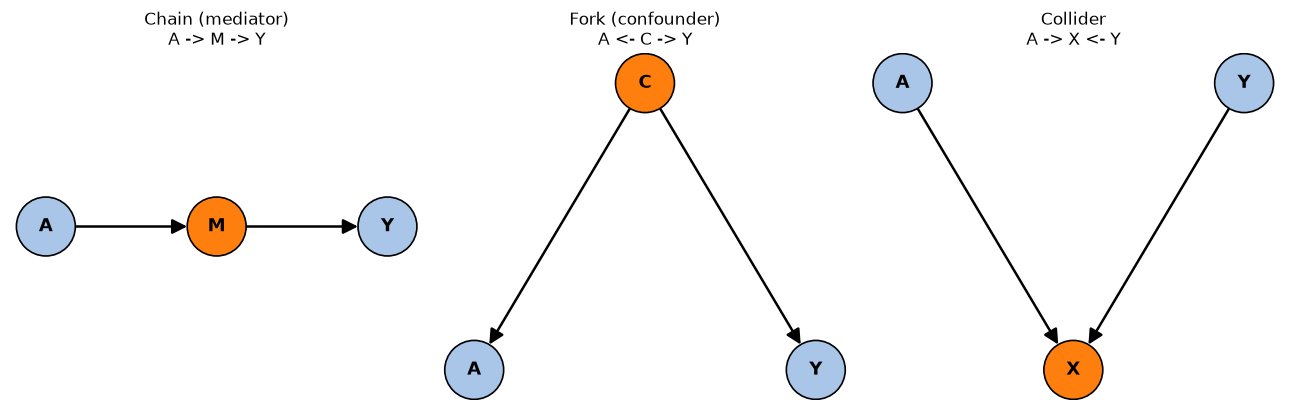

In [2]:

import matplotlib.pyplot as plt
import networkx as nx

def draw_dag(ax, edges, pos, title, highlight=None):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    node_colors = ["tab:orange" if highlight and n == highlight else "#a9c6e8" for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1800, node_color=node_colors,
                            edgecolors="black", linewidths=1.2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=13, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, arrowsize=22, node_size=1800,
                            width=1.8, connectionstyle="arc3,rad=0.0")
    ax.set_title(title, fontsize=12)
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

pos_chain = {"A": (0, 0), "M": (1, 0), "Y": (2, 0)}
draw_dag(axes[0], [("A", "M"), ("M", "Y")], pos_chain,
         "Chain (mediator)\nA -> M -> Y", highlight="M")

pos_fork = {"C": (1, 1), "A": (0, 0), "Y": (2, 0)}
draw_dag(axes[1], [("C", "A"), ("C", "Y")], pos_fork,
         "Fork (confounder)\nA <- C -> Y", highlight="C")

pos_collider = {"A": (0, 0), "X": (1, -1), "Y": (2, 0)}
draw_dag(axes[2], [("A", "X"), ("Y", "X")], pos_collider,
         "Collider\nA -> X <- Y", highlight="X")

plt.tight_layout()
plt.savefig("three_structures.png", dpi=130)
plt.show()



The orange node is the "middle" variable in each structure — and, per
section 3.3, it's the one whose treatment (condition on it, or don't)
flips the answer for whether $A$ and $Y$ end up statistically associated
through that path.

Now the DAG we'll actually use for the birth-weight analysis: maternal
**smoking** ($A$) affecting **birth weight** ($Y$), with mother's **age**
and **education** as confounders (they plausibly affect both whether a
mother smokes and the baby's birth weight through entirely separate
mechanisms), and **prenatal care visits** as a mediator-*and*-confounder —
we'll discuss below why it's treated as a confounder for this analysis.


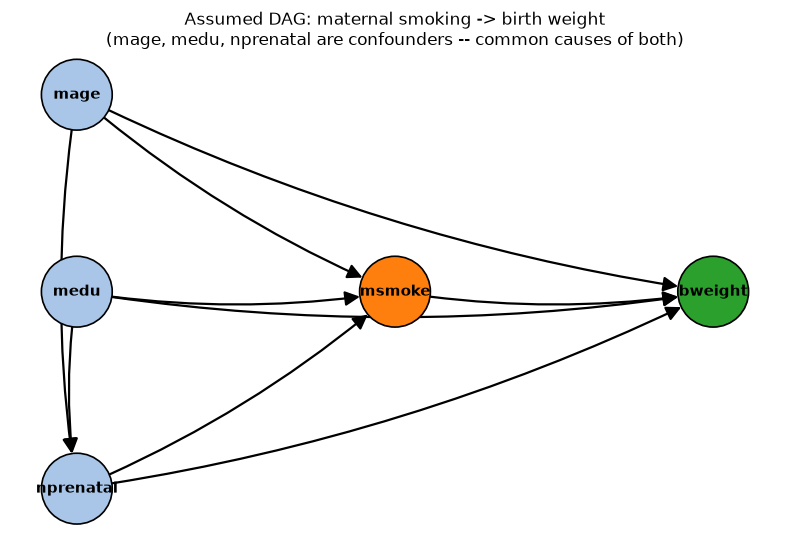

In [3]:

fig, ax = plt.subplots(figsize=(8, 5.5))

edges = [
    ("mage", "msmoke"), ("mage", "bweight"), ("mage", "nprenatal"),
    ("medu", "msmoke"), ("medu", "bweight"), ("medu", "nprenatal"),
    ("nprenatal", "msmoke"), ("nprenatal", "bweight"),
    ("msmoke", "bweight"),
]
G = nx.DiGraph()
G.add_edges_from(edges)
pos = {
    "mage": (0, 2), "medu": (0, 1), "nprenatal": (0, 0),
    "msmoke": (2, 1), "bweight": (4, 1),
}
node_colors = {"msmoke": "tab:orange", "bweight": "tab:green"}
colors = [node_colors.get(n, "#a9c6e8") for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2600, node_color=colors,
                        edgecolors="black", linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=ax, arrowsize=22, node_size=2600, width=1.6,
                        connectionstyle="arc3,rad=0.08")
ax.set_title("Assumed DAG: maternal smoking -> birth weight\n"
              "(mage, medu, nprenatal are confounders -- common causes of both)")
ax.axis("off")
plt.tight_layout()
plt.savefig("smoking_dag.png", dpi=130)
plt.show()



Every backdoor path from `msmoke` to `bweight` in this DAG runs through
`mage`, `medu`, or `nprenatal` (e.g. `msmoke <- mage -> bweight`). By the
backdoor criterion, adjusting for $\{$`mage`, `medu`, `nprenatal`$\}$ blocks
all of them, none of the three is a descendant of `msmoke`, so this is a
valid adjustment set for the effect of smoking on birth weight — *provided*
the DAG itself is correct (more on that leap of faith in section 7).



## 5. Implementation: smoking, confounding, and birth weight

**Data**: `cattaneo2.dta` — birth records used in Cattaneo (2010) and
distributed with Cunningham's *Causal Inference: The Mixtape* (2021). 4,642
singleton births; outcome `bweight` (birth weight in grams); treatment
`mbsmoke` (whether the mother smoked during pregnancy, already coded as a
clean binary `Smoker`/`Nonsmoker` factor); candidate confounders include
`mage` (mother's age), `medu` (mother's years of education), `fage`/`fedu`
(father's), `nprenatal` (number of prenatal care visits), `mmarried`,
`alcohol`, `deadkids`, and more.


In [4]:

cattaneo = pd.read_stata(
    "https://raw.githubusercontent.com/scunning1975/mixtape/master/cattaneo2.dta"
)
print(cattaneo.shape)
cattaneo[["bweight", "mage", "medu", "fage", "fedu", "nprenatal",
          "mmarried", "alcohol", "deadkids"]].describe().round(2)


(4642, 23)


,bweight,mage,medu,fage,fedu,nprenatal,alcohol,deadkids
count,4642.00,4642.00,4642.00,4642.00,4642.00,4642.00,4642.00,4642.00
mean,3361.68,26.50,12.69,27.27,12.31,10.76,0.03,0.26
std,578.82,5.62,2.52,9.35,3.68,3.68,0.18,0.44
min,340.00,13.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3033.00,22.00,12.00,24.00,12.00,9.00,0.00,0.00
50%,3390.00,26.00,12.00,28.00,12.00,11.00,0.00,0.00
75%,3725.00,30.00,14.00,33.00,14.00,13.00,0.00,1.00
max,5500.00,45.00,17.00,60.00,17.00,40.00,1.00,1.00


In [5]:

print(cattaneo["mbsmoke"].value_counts())
print()
print(cattaneo["msmoke"].value_counts())  # raw intensity categories, for reference


mbsmoke
Nonsmoker    3778
Smoker        864
Name: count, dtype: int64

msmoke
0 daily       3778
6–10 daily     337
11+ daily      327
1–5 daily      200
Name: count, dtype: int64



`mbsmoke` is already a clean binary treatment (`Smoker` vs. `Nonsmoker`),
built from the finer `msmoke` intensity categories — we'll use `mbsmoke`
directly rather than re-deriving it, since re-binarizing `msmoke` ourselves
would just reproduce the same variable with more room for error.

### 5.1 The naive (unadjusted) association

The naive estimate simply compares average birth weight between smokers and
non-smokers, with no adjustment — exactly the comparison you'd make if you
'd never drawn a DAG at all.


In [6]:

cattaneo["smoker"] = (cattaneo["mbsmoke"] == "Smoker").astype(int)

naive_gap = (cattaneo.loc[cattaneo.smoker == 1, "bweight"].mean()
             - cattaneo.loc[cattaneo.smoker == 0, "bweight"].mean())
print(f"Mean birth weight, non-smokers : {cattaneo.loc[cattaneo.smoker == 0, 'bweight'].mean():,.1f} g")
print(f"Mean birth weight, smokers     : {cattaneo.loc[cattaneo.smoker == 1, 'bweight'].mean():,.1f} g")
print(f"Naive (unadjusted) gap         : {naive_gap:,.1f} g")


Mean birth weight, non-smokers : 3,412.9 g
Mean birth weight, smokers     : 3,137.7 g
Naive (unadjusted) gap         : -275.3 g


In [7]:

import statsmodels.formula.api as smf

naive_model = smf.ols("bweight ~ smoker", data=cattaneo).fit(cov_type="HC1")
print(naive_model.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3412.9116      9.285    367.555      0.000    3394.712    3431.111
smoker      -275.2519     21.215    -12.974      0.000    -316.833    -233.671



### 5.2 The backdoor-adjusted estimate

Per the DAG in section 4, `mage`, `medu`, and `nprenatal` are confounders:
plausible common causes of both smoking status and birth weight (younger,
less-educated mothers with less prenatal care are, on average, both more
likely to smoke *and* more likely to have lower-birth-weight babies for
reasons unrelated to smoking itself — nutrition, stress, healthcare access).
None of the three is caused *by* smoking, so none is a mediator or a
collider — they satisfy the backdoor criterion's two conditions. We adjust
by adding them as controls in the regression (the linear-model equivalent
of the backdoor adjustment formula from section 3.4).


In [8]:

adjusted_model = smf.ols(
    "bweight ~ smoker + mage + medu + nprenatal", data=cattaneo
).fit(cov_type="HC1")
print(adjusted_model.summary().tables[1])

naive_effect = naive_model.params["smoker"]
adjusted_effect = adjusted_model.params["smoker"]
print(f"\nNaive smoking effect on birth weight    : {naive_effect:,.1f} g")
print(f"Backdoor-adjusted smoking effect         : {adjusted_effect:,.1f} g")
print(f"Adjustment moved the estimate by         : {adjusted_effect - naive_effect:,.1f} g")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2887.6978     55.921     51.639      0.000    2778.095    2997.301
smoker      -227.6311     21.764    -10.459      0.000    -270.288    -184.974
mage           4.8520      1.680      2.887      0.004       1.559       8.145
medu           3.5912      3.383      1.062      0.288      -3.038      10.221
nprenatal     31.8067      2.860     11.122      0.000      26.202      37.412

Naive smoking effect on birth weight    : -275.3 g
Backdoor-adjusted smoking effect         : -227.6 g
Adjustment moved the estimate by         : 47.6 g



### 5.3 What adjusting for the *wrong* set does

To make the backdoor criterion's warning concrete: `nprenatal` (number of
prenatal visits) could plausibly also be a **mediator** if smoking itself
changes how often a mother seeks prenatal care. If that were the true DAG
($A \to \text{nprenatal} \to Y$ as well as $A \to Y$ directly), adjusting
for `nprenatal` would partially block the very effect we're estimating. We
don't have a way to settle which story is right from the data alone (that's
the point of section 7) — but we can show the effect adjusting for a true
descendant of treatment has, using birth weight's own indicator `lbweight`
(low birth weight, itself a transformation of `bweight`) as a deliberately
wrong, extreme example of conditioning on a descendant of the outcome:


In [9]:

# lbweight is defined FROM bweight (a descendant of the outcome, not a
# pre-treatment confounder) -- adjusting for it is exactly the mistake the
# backdoor criterion's "no descendants of A" rule (and simple logic) rules out.
wrong_model = smf.ols(
    "bweight ~ smoker + mage + medu + nprenatal + lbweight", data=cattaneo
).fit(cov_type="HC1")
print(wrong_model.summary().tables[1])
print(f"\nSmoking effect, correct adjustment set   : {adjusted_effect:,.1f} g")
print(f"Smoking effect, + lbweight (wrong)       : {wrong_model.params['smoker']:,.1f} g")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3139.1952     41.875     74.966      0.000    3057.122    3221.268
smoker      -163.1105     16.866     -9.671      0.000    -196.167    -130.054
mage           4.7058      1.316      3.575      0.000       2.126       7.286
medu           2.1048      2.788      0.755      0.450      -3.359       7.569
nprenatal     17.0500      2.038      8.367      0.000      13.056      21.044
lbweight   -1359.6923     33.209    -40.944      0.000   -1424.780   -1294.604

Smoking effect, correct adjustment set   : -227.6 g
Smoking effect, + lbweight (wrong)       : -163.1 g



Adjusting for a variable *derived from the outcome itself* collapses the
estimated smoking effect dramatically — not because smoking stopped
mattering, but because we handed the regression a stand-in for the outcome
and asked it to explain birth weight *given* birth weight. This is an
intentionally extreme version of the collider/mediator mistake from section
3.4: the fix is never "add more controls," it's "add the controls the DAG
says you need, and only those."

**Reported numbers**: the naive gap, the backdoor-adjusted gap (our best
estimate under the assumed DAG), and the wrong-adjustment-set gap are all
computed live above from `cattaneo2.dta` — no placeholders.



## 6. Use cases

- **Epidemiology**: DAGs are the standard tool for pre-registering which
  covariates an observational study will adjust for, *before* looking at
  the outcome data — exactly the workflow in section 5 (Greenland, Pearl &
  Robins, 1999, formalized this for epidemiology specifically).
- **Economics and policy evaluation**: DAGs are used alongside (and are
  mathematically equivalent to) potential-outcomes reasoning to justify
  which controls belong in a regression, and to explain instrumental
  variables / regression-discontinuity designs graphically.
- **Algorithmic fairness audits**: whether a "proxy" variable (e.g. zip
  code) should be excluded from a model often reduces to whether it's a
  mediator of a protected attribute's effect vs. an independent predictor
  — a DAG question.
- **Causal discovery / structure learning**: algorithms like PC and FCI try
  to *learn* a DAG's edges (or an equivalence class of them) directly from
  observational data, using exactly the d-separation implications this
  tutorial derived, run in reverse.
- **`dowhy` and other causal-inference libraries**: modern tools like
  Microsoft's `dowhy` take a DAG as direct input and automatically find
  valid backdoor adjustment sets, refute the resulting estimate against
  alternative specifications, and flag when no valid adjustment set exists.



## 7. Limitations & debates

- **The DAG itself is an untestable, a priori assumption.** Nothing in the
  data can prove `mage -> msmoke -> bweight` is the correct structure
  rather than some other arrangement of the same variables — the graph
  encodes domain knowledge and judgment calls (like the `nprenatal`
  mediator-or-confounder ambiguity in section 5.3) that data alone cannot
  adjudicate. Two well-informed analysts can draw different DAGs for the
  same problem and reach different "correct" adjustment sets.
- **Unmeasured confounders break the backdoor criterion silently.** The
  method only works if every relevant common cause is (a) known to exist,
  and (b) actually measured and included in $Z$. If, say, some unmeasured
  factor (genetic predisposition, household stress) causes both smoking and
  birth weight, the backdoor-adjusted estimate in section 5.2 is still
  biased — and nothing in the regression output warns you this happened.
  Sensitivity analysis (asking "how strong would an unmeasured confounder
  need to be to overturn this result?") is the standard partial remedy, not
  a full fix.
- **Real systems are rarely 3-node toy graphs.** Practical DAGs for
  epidemiology, economics, or tech products can have dozens of nodes and
  hundreds of paths; finding a valid, minimal adjustment set by hand
  becomes infeasible, which is exactly what automated tools like `dowhy`'s
  backdoor-identification algorithms are for. More nodes also means more
  ways to accidentally condition on a collider without realizing it
  (e.g. conditioning on a variable several steps downstream of one).
- **DAGs vs. potential outcomes is a live methodological conversation, not
  a settled turf war.** Pearl's structural causal models (graphical,
  built around $do(\cdot)$-calculus) and Rubin's potential-outcomes
  framework (the companion tutorial's approach) are provably
  **mathematically equivalent** in what they can identify (Pearl, 2009,
  ch. 7) — but practitioners in different fields have historically
  preferred one language over the other, and the two camps have publicly
  disagreed about which is more useful pedagogically and practically (see
  the pointed Pearl/Rubin-tradition exchanges summarized in Pearl &
  Mackenzie, 2018, and Imbens's 2020 JEL response defending the
  potential-outcomes tradition's practical track record). This tutorial and
  its companion are two dialects of the same underlying theory, not
  competing theories.
- **A DAG tells you what to adjust for; it does not tell you your
  functional form is right.** The backdoor criterion justifies *which*
  variables belong in $Z$; whether a linear OLS control for them (as used
  in section 5) is a good enough approximation of $P(Y \mid A, Z)$ is a
  separate modeling assumption, and nonlinear confounding relationships can
  still bias a linear adjustment even when the adjustment *set* is
  correct.



## 8. References

- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd
  ed.). Cambridge University Press.
- Pearl, J. (1988). *Probabilistic Reasoning in Intelligent Systems.*
  Morgan Kaufmann. (introduces d-separation)
- Pearl, J. (1993). *Comment: Graphical Models, Causality, and
  Intervention.* Statistical Science 8(3). (backdoor criterion)
- Pearl, J. & Mackenzie, D. (2018). *The Book of Why: The New Science of
  Cause and Effect.* Basic Books.
- Greenland, S., Pearl, J., & Robins, J. M. (1999). *Causal Diagrams for
  Epidemiologic Research.* Epidemiology 10(1).
- Imbens, G. W. (2020). *Potential Outcome and Directed Acyclic Graph
  Approaches to Causality: Relevance for Empirical Practice in Economics.*
  Journal of Economic Literature 58(4).
- Cattaneo, M. D. (2010). *Efficient Semiparametric Estimation of
  Multi-Valued Treatment Effects Under Ignorability.* Journal of
  Econometrics 155(2). (source of the `cattaneo2.dta` dataset used here)
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press.
- Holland, P. W. (1986). *Statistics and Causal Inference.* JASA 81(396).
